In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("European_Bank_Cleaned_Featured.csv")

print("Dataset shape:", df.shape)

Dataset shape: (10000, 29)


In [2]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,Balance_Segment,Salary_Segment,Product_Depth_Group,Engagement_Status,Engagement_Profile,High_Value_Customer,High_Value_Disengaged,Customer_Value_Segment,Credit_Card_Status,Engagement_Score,Initial_Retention_Risk,Balance_to_Salary_Ratio,Financial_Segment,Churn_Status
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,36-45,Low Balance,High Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Card Holder,70,Low Risk,0.000000,High Salary - Low Balance,Churned
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,36-45,Medium Balance,High Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Non Card Holder,50,Low Risk,0.744677,High Salary - Low Balance,Retained
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,36-45,Very High Balance,High Salary,3+ Products,Inactive,Inactive Multi-Product,1,1,High Value - Disengaged,Card Holder,50,High Risk,1.401375,High Salary - High Balance,Churned
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,36-45,Low Balance,Medium Salary,Two Products,Inactive,Inactive Multi-Product,0,0,Standard Value - Disengaged,Non Card Holder,30,Medium Risk,0.000000,Low Salary - Low Balance,Retained
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,36-45,High Balance,Medium Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Card Holder,70,Low Risk,1.587055,Low Salary - High Balance,Retained


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,10000.0,NaN,NaN,NaN,2025.0,0.0,2025.0,2025.0,2025.0,2025.0,2025.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     10000 non-null  int64  
 1   CustomerId               10000 non-null  int64  
 2   Surname                  10000 non-null  object 
 3   CreditScore              10000 non-null  int64  
 4   Geography                10000 non-null  object 
 5   Gender                   10000 non-null  object 
 6   Age                      10000 non-null  int64  
 7   Tenure                   10000 non-null  int64  
 8   Balance                  10000 non-null  float64
 9   NumOfProducts            10000 non-null  int64  
 10  HasCrCard                10000 non-null  int64  
 11  IsActiveMember           10000 non-null  int64  
 12  EstimatedSalary          10000 non-null  float64
 13  Exited                   10000 non-null  int64  
 14  Age_Group              

In [5]:
total_customers = len(df)

churned_customers = df["Exited"].sum()

retained_customers = total_customers - churned_customers

churn_rate = df["Exited"].mean() * 100

active_rate = df["IsActiveMember"].mean() * 100

card_ownership_rate = df["HasCrCard"].mean() * 100

avg_products = df["NumOfProducts"].mean()

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Active Customer Rate:", round(active_rate, 2), "%")
print("Credit Card Ownership:", round(card_ownership_rate, 2), "%")
print("Average Products:", round(avg_products, 2))

Total Customers: 10000
Churned Customers: 2037
Retained Customers: 7963
Churn Rate: 20.37 %
Active Customer Rate: 51.51 %
Credit Card Ownership: 70.55 %
Average Products: 1.53


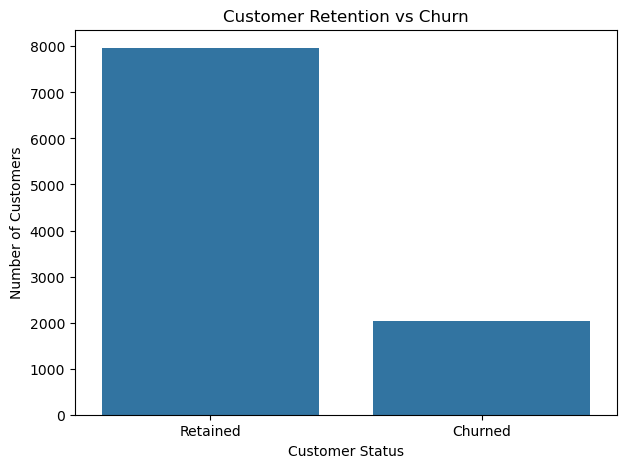

In [6]:
churn_counts = df["Churn_Status"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Retention vs Churn")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

In [7]:
def churn_summary(data, group_col):
    
    result = (
        data.groupby(group_col)
        .agg(
            Customers=("CustomerId", "count"),
            Churned=("Exited", "sum"),
            Churn_Rate=("Exited", "mean")
        )
        .reset_index()
    )
    
    result["Churn_Rate"] = result["Churn_Rate"] * 100
    
    return result.sort_values(
        "Churn_Rate",
        ascending=False
    )

In [8]:
churn_summary(df, "Geography")

,Geography,Customers,Churned,Churn_Rate
1,Germany,2509,814,32.443204
2,Spain,2477,413,16.673395
0,France,5014,810,16.154767


In [9]:
geo_churn = churn_summary(df, "Geography")

geo_churn

,Geography,Customers,Churned,Churn_Rate
1,Germany,2509,814,32.443204
2,Spain,2477,413,16.673395
0,France,5014,810,16.154767


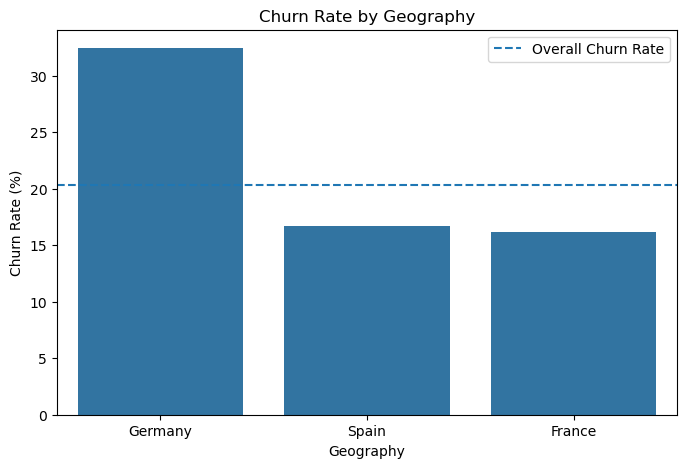

In [10]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=geo_churn,
    x="Geography",
    y="Churn_Rate"
)

plt.axhline(
    churn_rate,
    linestyle="--",
    label="Overall Churn Rate"
)

plt.title("Churn Rate by Geography")
plt.ylabel("Churn Rate (%)")
plt.legend()

plt.show()

In [11]:
gender_churn = churn_summary(df, "Gender")

gender_churn

,Gender,Customers,Churned,Churn_Rate
0,Female,4543,1139,25.071539
1,Male,5457,898,16.455928


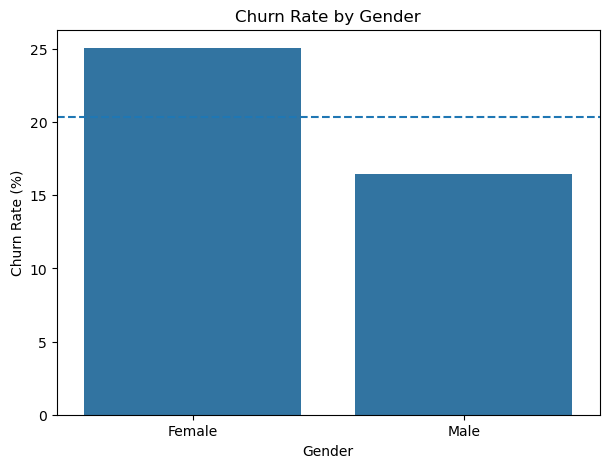

In [12]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_churn,
    x="Gender",
    y="Churn_Rate"
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

In [13]:
age_churn = churn_summary(df, "Age_Group")

age_churn

,Age_Group,Customers,Churned,Churn_Rate
3,46-55,1311,663,50.572082
4,56+,800,294,36.750000
2,36-45,3736,733,19.619914
1,26-35,3542,301,8.498024
0,18-25,611,46,7.528642


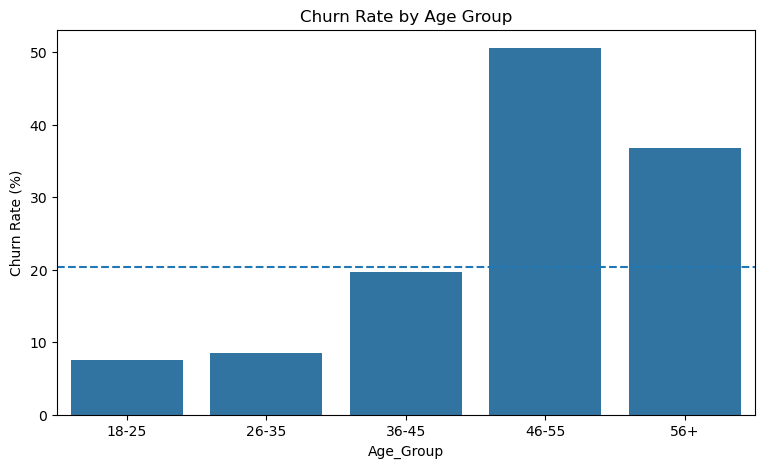

In [14]:
age_order = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_churn,
    x="Age_Group",
    y="Churn_Rate",
    order=age_order
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Age Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [15]:
credit_bins = [349, 579, 669, 739, 799, 850]

credit_labels = [
    "Poor",
    "Fair",
    "Good",
    "Very Good",
    "Excellent"
]

df["Credit_Score_Group"] = pd.cut(
    df["CreditScore"],
    bins=credit_bins,
    labels=credit_labels
)


In [16]:
credit_churn = churn_summary(
    df,
    "Credit_Score_Group"
)

credit_churn

C:\Users\HP\AppData\Local\Temp\ipykernel_2596\1050241715.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(group_col)


,Credit_Score_Group,Customers,Churned,Churn_Rate
0,Poor,2362,520,22.015241
3,Very Good,1224,252,20.588235
1,Fair,3331,685,20.564395
4,Excellent,655,128,19.541985
2,Good,2428,452,18.616145


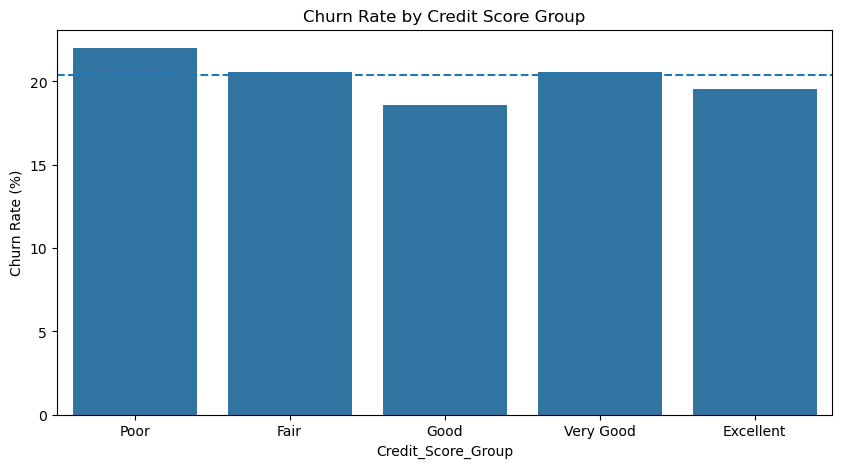

In [17]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=credit_churn,
    x="Credit_Score_Group",
    y="Churn_Rate",
    order=credit_labels
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Credit Score Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [18]:
tenure_churn = churn_summary(df, "Tenure")

tenure_churn

,Tenure,Customers,Churned,Churn_Rate
0,0,413,95,23.002421
1,1,1035,232,22.415459
9,9,984,213,21.646341
3,3,1009,213,21.110010
5,5,1012,209,20.652174
10,10,490,101,20.612245
4,4,989,203,20.525784
6,6,967,196,20.268873
8,8,1025,197,19.219512
2,2,1048,201,19.179389


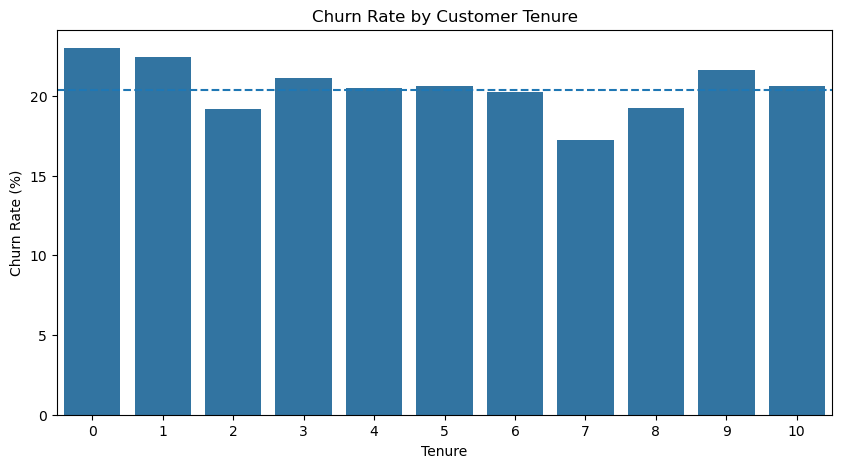

In [19]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=tenure_churn,
    x="Tenure",
    y="Churn_Rate"
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Customer Tenure")
plt.ylabel("Churn Rate (%)")

plt.show()

In [20]:
balance_churn = churn_summary(
    df,
    "Balance_Segment"
)

balance_churn

,Balance_Segment,Customers,Churned,Churn_Rate
0,High Balance,2500,657,26.28
3,Very High Balance,2500,592,23.68
2,Medium Balance,2500,422,16.88
1,Low Balance,2500,366,14.64


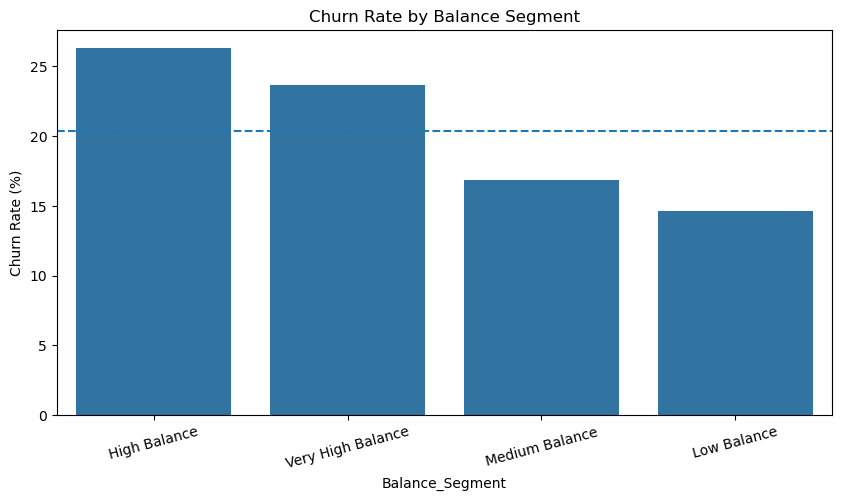

In [21]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=balance_churn,
    x="Balance_Segment",
    y="Churn_Rate"
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Balance Segment")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=15)

plt.show()

In [22]:
salary_churn = churn_summary(
    df,
    "Salary_Segment"
)

salary_churn

,Salary_Segment,Customers,Churned,Churn_Rate
3,Very High Salary,2500,539,21.56
0,High Salary,2500,503,20.12
1,Low Salary,2500,500,20.00
2,Medium Salary,2500,495,19.80


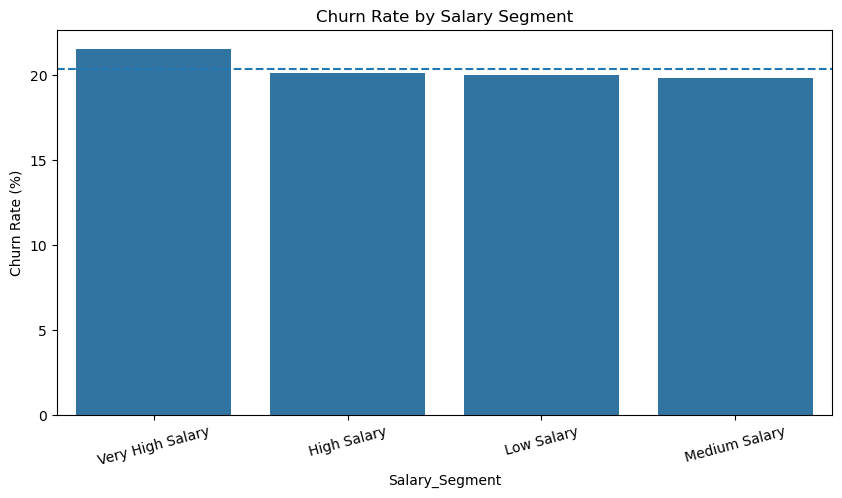

In [23]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=salary_churn,
    x="Salary_Segment",
    y="Churn_Rate"
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Salary Segment")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=15)

plt.show()

In [24]:
card_churn = churn_summary(
    df,
    "Credit_Card_Status"
)

card_churn

,Credit_Card_Status,Customers,Churned,Churn_Rate
1,Non Card Holder,2945,613,20.814941
0,Card Holder,7055,1424,20.184266


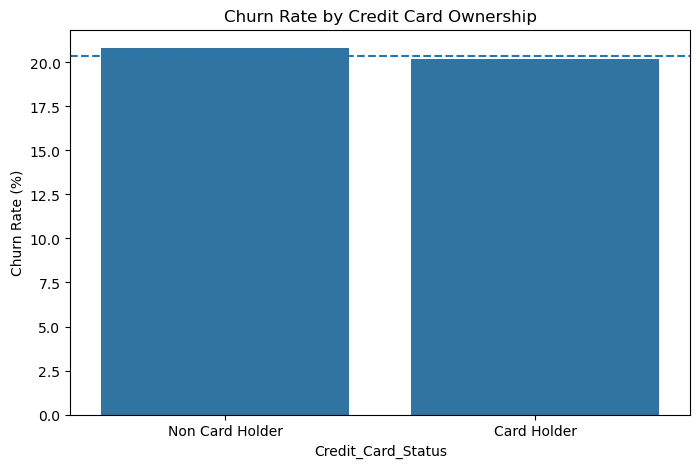

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=card_churn,
    x="Credit_Card_Status",
    y="Churn_Rate"
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Credit Card Ownership")
plt.ylabel("Churn Rate (%)")

plt.show()

In [26]:
engagement_churn = churn_summary(
    df,
    "Engagement_Status"
)

engagement_churn

,Engagement_Status,Customers,Churned,Churn_Rate
1,Inactive,4849,1302,26.850897
0,Active,5151,735,14.269074


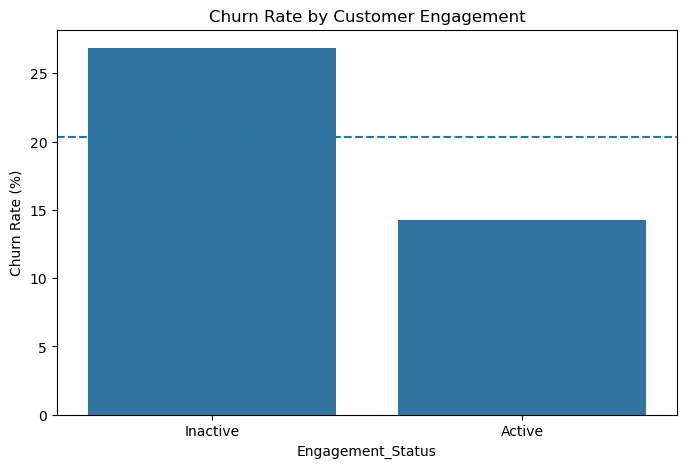

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=engagement_churn,
    x="Engagement_Status",
    y="Churn_Rate"
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Customer Engagement")
plt.ylabel("Churn Rate (%)")

plt.show()

In [28]:
active_churn = (
    df.loc[df["IsActiveMember"] == 1, "Exited"]
    .mean()
)

inactive_churn = (
    df.loc[df["IsActiveMember"] == 0, "Exited"]
    .mean()
)

engagement_retention_ratio = inactive_churn / active_churn

print(
    "Active churn rate:",
    round(active_churn * 100, 2), "%"
)

print(
    "Inactive churn rate:",
    round(inactive_churn * 100, 2), "%"
)

print(
    "Inactive-to-active churn ratio:",
    round(engagement_retention_ratio, 2)
)

Active churn rate: 14.27 %
Inactive churn rate: 26.85 %
Inactive-to-active churn ratio: 1.88


In [29]:
product_churn = churn_summary(
    df,
    "NumOfProducts"
)

product_churn

,NumOfProducts,Customers,Churned,Churn_Rate
3,4,60,60,100.000000
2,3,266,220,82.706767
0,1,5084,1409,27.714398
1,2,4590,348,7.581699


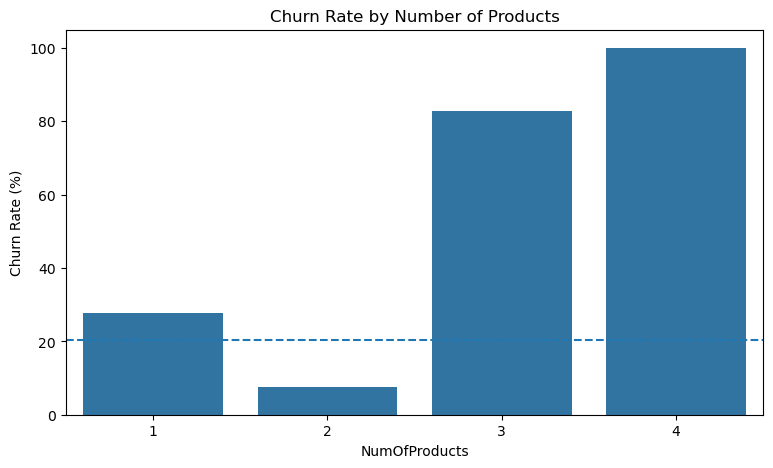

In [30]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=product_churn,
    x="NumOfProducts",
    y="Churn_Rate"
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

In [31]:
product_group_churn = churn_summary(
    df,
    "Product_Depth_Group"
)

product_group_churn

,Product_Depth_Group,Customers,Churned,Churn_Rate
0,3+ Products,326,280,85.889571
1,Single Product,5084,1409,27.714398
2,Two Products,4590,348,7.581699


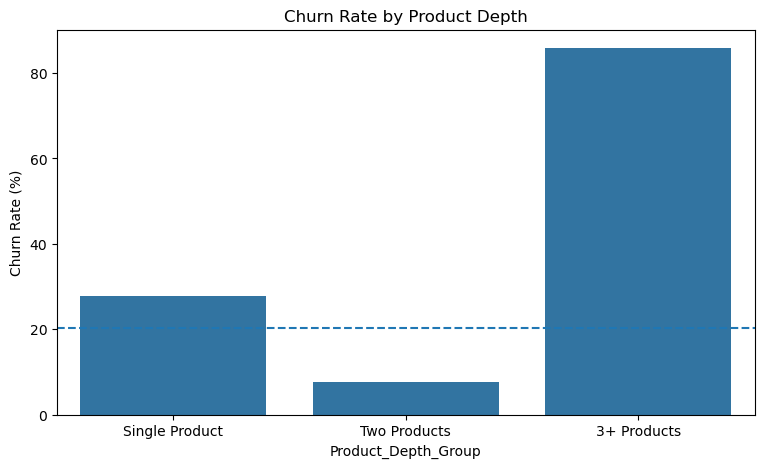

In [32]:
product_order = [
    "Single Product",
    "Two Products",
    "3+ Products"
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=product_group_churn,
    x="Product_Depth_Group",
    y="Churn_Rate",
    order=product_order
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Product Depth")
plt.ylabel("Churn Rate (%)")

plt.show()

In [33]:
profile_churn = churn_summary(
    df,
    "Engagement_Profile"
)

profile_churn

,Engagement_Profile,Customers,Churned,Churn_Rate
2,Inactive Disengaged,2521,924,36.652122
1,Active Low-Product,2563,485,18.923137
3,Inactive Multi-Product,2328,378,16.237113
0,Active Engaged,2588,250,9.659969


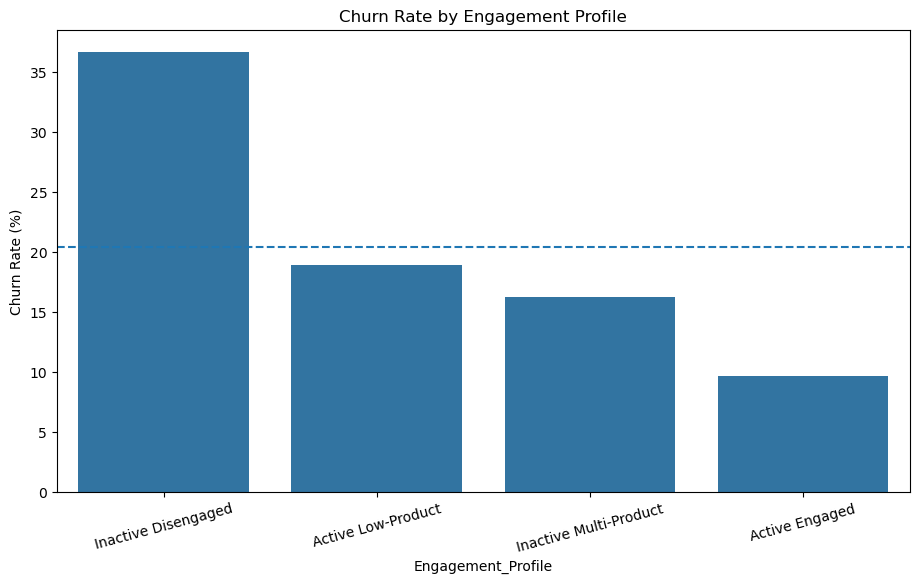

In [34]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=profile_churn,
    x="Engagement_Profile",
    y="Churn_Rate"
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Engagement Profile")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=15)

plt.show()

In [35]:
high_value_churn = churn_summary(
    df,
    "High_Value_Disengaged"
)

high_value_churn

,High_Value_Disengaged,Customers,Churned,Churn_Rate
1,1,1247,380,30.473136
0,0,8753,1657,18.930652


In [36]:
df["High_Value_Disengaged_Label"] = np.where(
    df["High_Value_Disengaged"] == 1,
    "High-Value Disengaged",
    "Other Customers"
)

high_value_label_churn = churn_summary(
    df,
    "High_Value_Disengaged_Label"
)

high_value_label_churn

,High_Value_Disengaged_Label,Customers,Churned,Churn_Rate
0,High-Value Disengaged,1247,380,30.473136
1,Other Customers,8753,1657,18.930652


In [37]:
value_churn = churn_summary(
    df,
    "Customer_Value_Segment"
)

value_churn

,Customer_Value_Segment,Customers,Churned,Churn_Rate
0,High Value - Disengaged,1247,380,30.473136
2,Standard Value - Disengaged,3602,922,25.596891
1,High Value - Engaged,1253,212,16.919393
3,Standard Value - Engaged,3898,523,13.417137


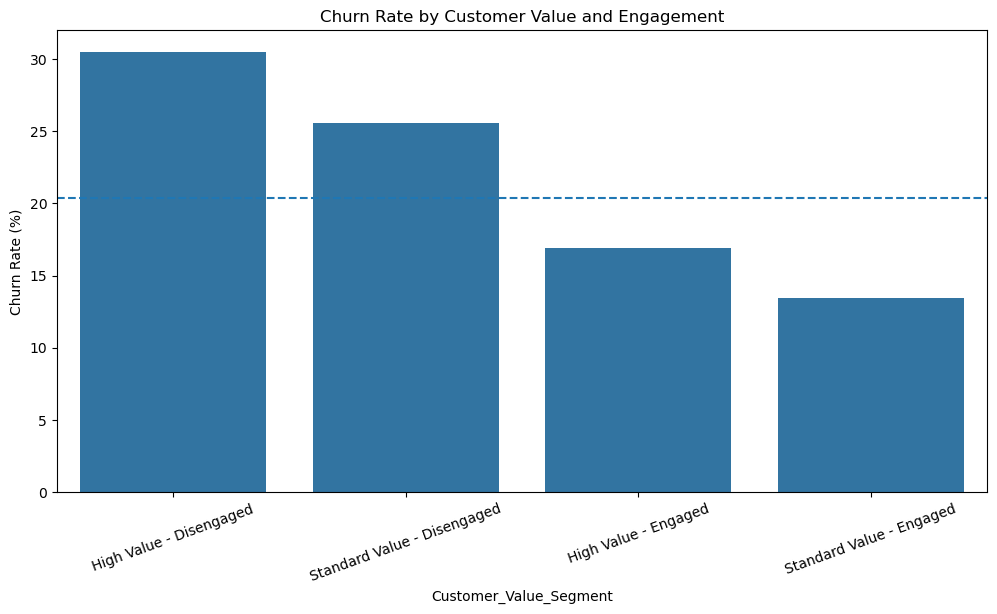

In [38]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=value_churn,
    x="Customer_Value_Segment",
    y="Churn_Rate"
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Customer Value and Engagement")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.show()

In [39]:
financial_churn = churn_summary(
    df,
    "Financial_Segment"
)

financial_churn

,Financial_Segment,Customers,Churned,Churn_Rate
0,High Salary - High Balance,2516,631,25.079491
2,Low Salary - High Balance,2484,618,24.879227
1,High Salary - Low Balance,2484,411,16.545894
3,Low Salary - Low Balance,2516,377,14.984102


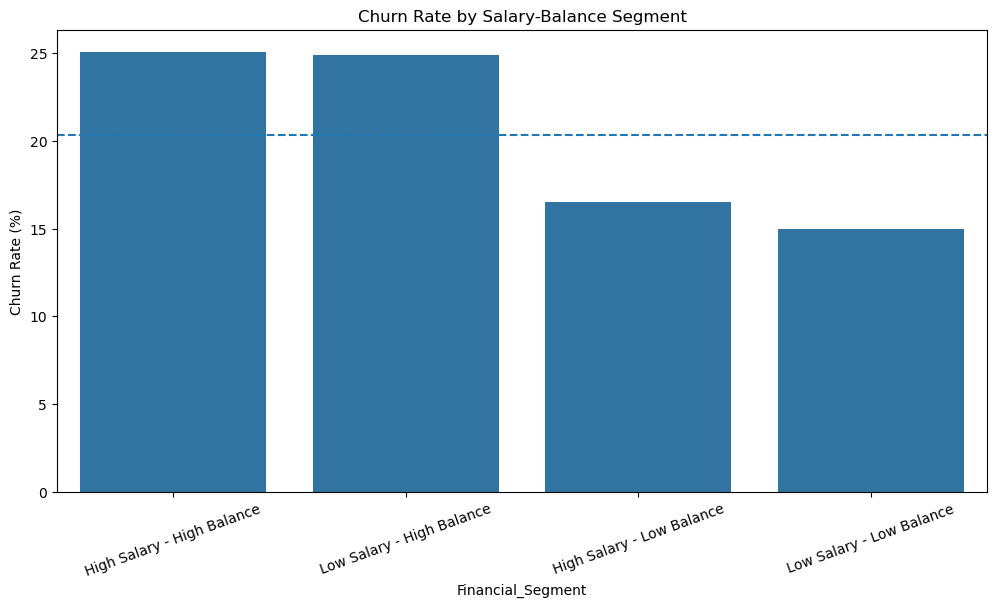

In [40]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=financial_churn,
    x="Financial_Segment",
    y="Churn_Rate"
)

plt.axhline(
    churn_rate,
    linestyle="--"
)

plt.title("Churn Rate by Salary-Balance Segment")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.show()

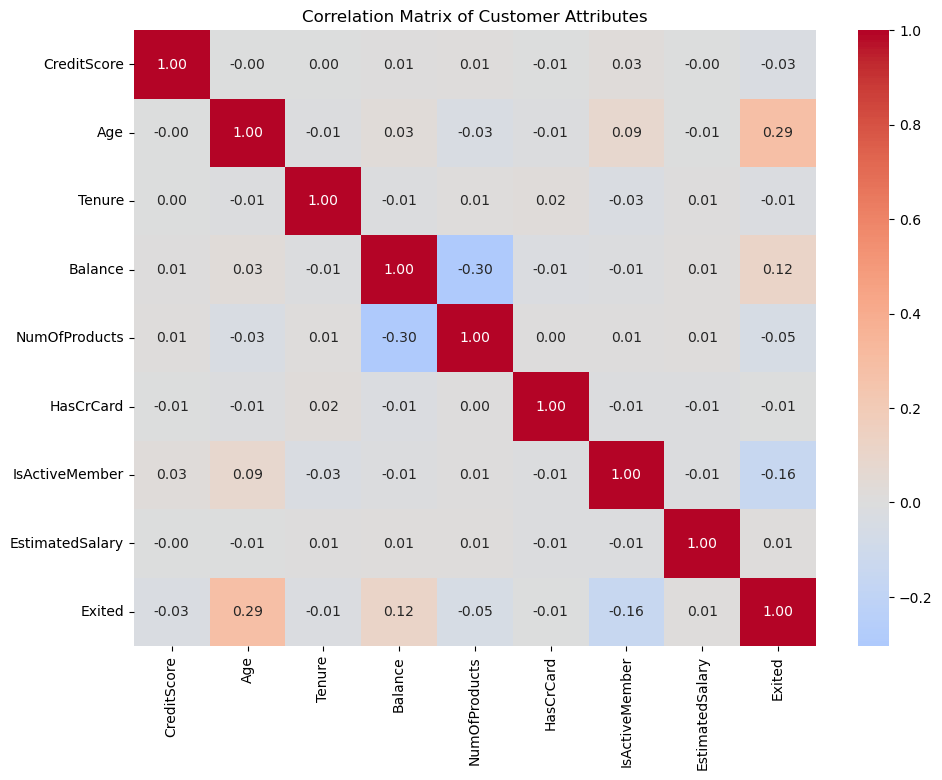

In [41]:
numeric_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Exited"
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Customer Attributes")

plt.show()

In [42]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Overall Churn",
        "Active Customer Churn",
        "Inactive Customer Churn",
        "Single Product Churn",
        "Two Product Churn",
        "High-Value Disengaged Churn"
    ],
    "Value": [
        df["Exited"].mean() * 100,
        df.loc[df["IsActiveMember"] == 1, "Exited"].mean() * 100,
        df.loc[df["IsActiveMember"] == 0, "Exited"].mean() * 100,
        df.loc[df["NumOfProducts"] == 1, "Exited"].mean() * 100,
        df.loc[df["NumOfProducts"] == 2, "Exited"].mean() * 100,
        df.loc[df["High_Value_Disengaged"] == 1, "Exited"].mean() * 100
    ]
})

eda_summary["Value"] = eda_summary["Value"].round(2)

eda_summary

,Metric,Value
0,Overall Churn,20.37
1,Active Customer Churn,14.27
2,Inactive Customer Churn,26.85
3,Single Product Churn,27.71
4,Two Product Churn,7.58
5,High-Value Disengaged Churn,30.47


In [43]:
insight_table = pd.DataFrame({
    "Analysis Area": [
        "Engagement",
        "Product Depth",
        "High-Value Customers",
        "Credit Card",
        "Geography"
    ],
    "Business Question": [
        "Does active engagement reduce churn?",
        "Does deeper product usage improve retention?",
        "Are financially valuable customers still at risk?",
        "Does card ownership create stickiness?",
        "Is churn concentrated geographically?"
    ]
})

insight_table

,Analysis Area,Business Question
0,Engagement,Does active engagement reduce churn?
1,Product Depth,Does deeper product usage improve retention?
2,High-Value Customers,Are financially valuable customers still at risk?
3,Credit Card,Does card ownership create stickiness?
4,Geography,Is churn concentrated geographically?


In [44]:
eda_summary.to_csv(
    "EDA_KPI_Summary.csv",
    index=False
)

In [45]:
df.to_csv(
    "European_Bank_EDA_Ready.csv",
    index=False
)